Responsible AI & Model Interpretation
Objective
The objective of this project is to analyze a machine learning model from the perspective of:

Model interpretability
Feature importance
Explainable AI (XAI)
Fairness and bias analysis
Responsible AI practices
A Random Forest classification model trained on the Breast Cancer Wisconsin dataset is analyzed.

The project uses SHAP (SHapley Additive exPlanations) to understand how individual features influence model predictions.

Goals
This analysis focuses on:

Understanding important model features
Explaining individual predictions
Identifying possible bias issues
Suggesting mitigation strategies


In [ ]:
!pip install shap


Import Required Libraries
The following libraries are used:

Pandas and NumPy for data handling
Scikit-learn for machine learning
SHAP for explainability
Matplotlib for visualization

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import shap

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

Dataset Description
The Breast Cancer Wisconsin Diagnostic Dataset is used for this responsible AI analysis.

The dataset contains:

569 medical observations
30 numerical features
Binary target classification
Target Classes:

0 - Malignant

1 - Benign

The dataset does not contain demographic sensitive attributes such as:

Gender
Race
Age
Therefore, direct fairness analysis across sensitive groups is not possible with this dataset.

In [ ]:
data = load_breast_cancer()


X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)


y = pd.Series(
    data.target
)


print(X.shape)

X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Model Training
A Random Forest classifier is trained because tree-based models provide:

Good classification performance
Built-in feature importance
Compatibility with SHAP explanations

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


model = RandomForestClassifier(
    random_state=42
)


model.fit(
    X_train,
    y_train
)


prediction = model.predict(X_test)


print(
    "Accuracy:",
    accuracy_score(y_test,prediction)
)

Accuracy: 0.9649122807017544


Feature Importance Analysis
Feature importance helps identify which input variables have the greatest influence on model predictions.

Random Forest calculates importance scores based on how much each feature contributes to decision making.

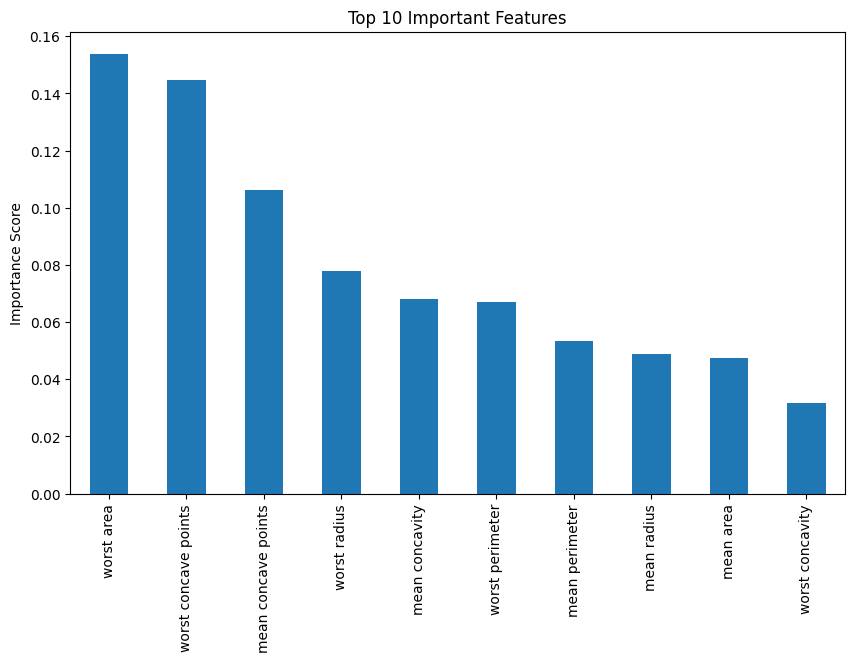

In [ ]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)


importance = importance.sort_values(
    ascending=False
)


plt.figure(figsize=(10,6))

importance.head(10).plot(
    kind="bar"
)


plt.title(
    "Top 10 Important Features"
)


plt.ylabel(
    "Importance Score"
)


plt.show()

SHAP Explainability
SHAP (SHapley Additive exPlanations) explains how each feature contributes to a model prediction.

It provides:

Global explanation of model behavior
Local explanation for individual predictions
Positive SHAP values increase the probability of a prediction.

Negative SHAP values decrease the probability.

In [ ]:
explainer = shap.TreeExplainer(
    model
)


shap_values = explainer.shap_values(
    X_test
)

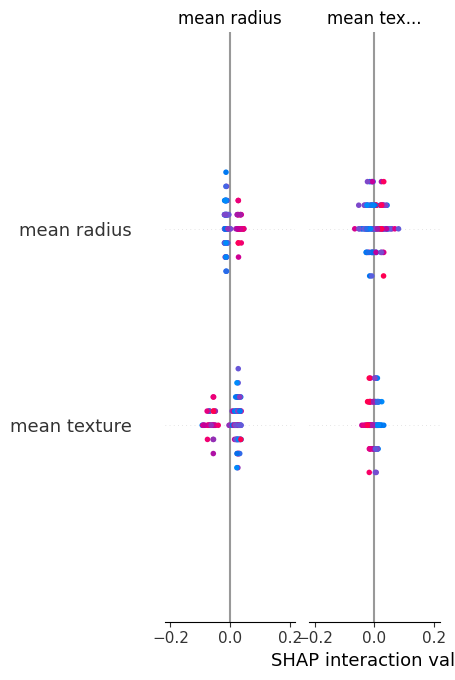

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    class_inds=1
)


Local Model Explanation
The following explanation shows how individual features influence one specific prediction.

This helps understand why the model classified a particular sample.

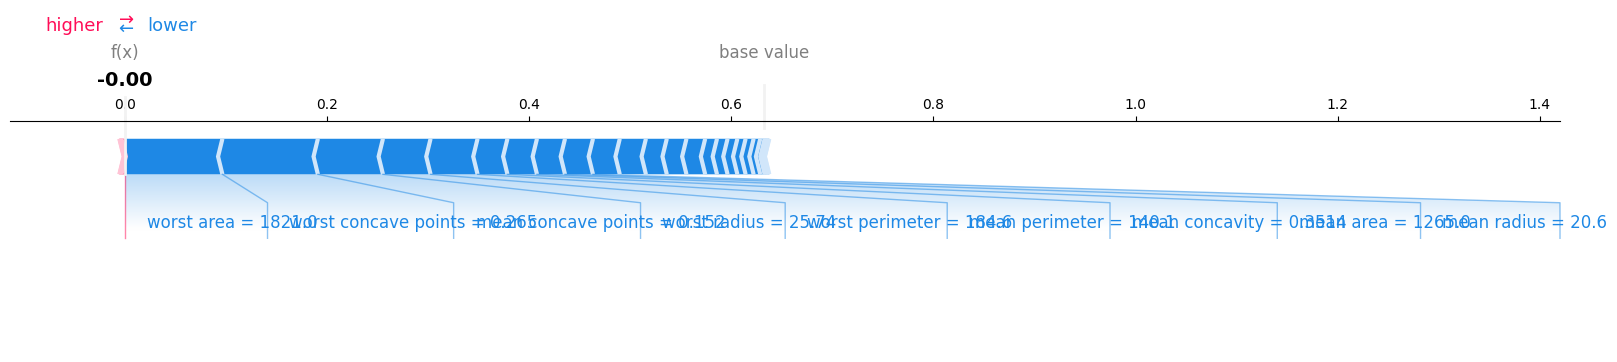

In [ ]:
sample_index = 5


shap.force_plot(
    explainer.expected_value[1],
    shap_values[sample_index, :, 1],
    X_test.iloc[sample_index],
    matplotlib=True
)

Bias and Fairness Analysis
Sensitive Attribute Check
The dataset was checked for sensitive attributes.

Available features are medical measurements such as:

Radius
Texture
Area
Smoothness
The dataset does not include:

Gender
Race
Age
Socioeconomic information
Therefore, group fairness metrics cannot be directly calculated.

Limitation
A complete fairness analysis requires demographic information to compare model performance across different groups.

Bias Mitigation Recommendations
Although sensitive attributes are unavailable, the following responsible AI practices are recommended:

1. Collect Representative Data
Training data should include diverse populations to reduce unfair outcomes.

2. Fairness Testing
Evaluate model performance separately across demographic groups.

Example metrics:

Equal opportunity
Demographic parity
Equalized odds
3. Data Balancing
If some groups are underrepresented:

Collect more samples
Use balanced sampling techniques
4. Human Oversight
Medical AI systems should support experts rather than replace human decision making.

5. Continuous Monitoring
Models should be regularly evaluated after deployment.

Conclusion
This project analyzed a Random Forest classification model using Responsible AI techniques.

The analysis included:

Feature importance visualization
SHAP-based model explanations
Local prediction interpretation
Bias and fairness considerations
Mitigation recommendations
Explainability methods help improve transparency and trust in machine learning systems.

Responsible AI requires not only accurate models but also fairness, accountability, and careful monitoring.